# 4.1 The SVD: Geometry, Existence, and the Four Subspaces Again

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter IV — The Singular Value Decomposition",
    number="4.1",
    title="The SVD: Geometry, Existence, and the Four Subspaces Again",
    blurb="Every matrix is a rotation, a scaling along axes, and another "
    "rotation. No hypotheses, no exceptions, orthonormal bases on both sides — "
    "which is why the previous three chapters kept ending with it.",
    difficulty="intermediate",
    estimate="90–120 min",
)

<ECP header: 2547 chars of HTML>

## Notebook overview

Three chapters have now ended by pointing here.
[§2.3](../02-orthogonality/least-squares-four-ways.ipynb) found the SVD still
working when the other three least-squares routes failed;
[§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb) built the
pseudoinverse out of it; [§3.5](../03-eigenvalues/schur-jordan-nonnormality.ipynb)
closed on the observation that every difficulty in Chapter III came from
eigenvalues of a non-normal matrix and that singular values have none of those
problems. This chapter takes the SVD as the subject rather than the tool.

The statement is unreasonably strong. **Every** matrix — rectangular, singular,
defective, complex, it does not matter — factors as
$A = U\Sigma V^{\top}$ with $U$ and $V$ orthogonal and $\Sigma$ diagonal with
non-negative entries. Compare what Chapter III needed: diagonalization required
$n$ independent eigenvectors, orthogonal diagonalization required normality, and
even then the eigenvalues could be complex and the eigenvector matrix badly
conditioned. Here there are no hypotheses at all, both bases are orthonormal
always, and the $\sigma_i$ are real and non-negative always.

Geometrically the factorization says a linear map is a **rotation, a scaling
along the axes, and another rotation** — and nothing else. The unit sphere maps
to an ellipsoid whose semi-axes are the $\sigma_i$ along the columns of $U$.
[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) already flagged
that those axes are *not* the eigenvectors for a non-symmetric matrix; this
notebook says what they are instead.

And the four subspaces of [§1.4](../01-matrices/four-subspaces.ipynb) fall out
by reading off column blocks: the first $r$ columns of $U$ span the column
space, the rest span the left null space, the first $r$ of $V$ span the row
space, the rest the null space. One factorization, all four subspaces, with
orthonormal bases for each.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own. Singular vectors carry
> the same sign freedom eigenvectors did, so the checks here compare
> projectors and reconstructions rather than columns.

> **Scope.** Trefethen and Bau {cite}`trefethen1997` Lectures 4–5 are the
> best short account anywhere; Strang {cite}`strang2023` Chapter 7; Golub and
> Van Loan {cite}`golub2013` §2.4 and Chapter 8.

## Theory in brief

### The factorization

For every $A \in \mathbb{R}^{m\times n}$ there exist orthogonal
$U \in \mathbb{R}^{m\times m}$ and $V \in \mathbb{R}^{n\times n}$ and a diagonal
$\Sigma \in \mathbb{R}^{m\times n}$ with
$\sigma_1 \ge \sigma_2 \ge \dots \ge 0$ such that

```{math}
:label: eq-svd-decomposition
A = U\Sigma V^{\top} .
```

That is the **full** SVD. If $A$ has rank $r$ then only the first $r$ singular
values are nonzero, and the **economy** form keeps only what contributes:
$U_r$ is $m\times r$, $\Sigma_r$ is $r\times r$, $V_r^{\top}$ is $r\times n$,
and $A = U_r\Sigma_rV_r^{\top}$ still. `np.linalg.svd(A, full_matrices=False)`
returns the economy form with $\min(m,n)$ columns.

### Where it comes from

Existence follows from [§3.2](../03-eigenvalues/spectral-theorem.ipynb). Both
$A^{\top}A$ and $AA^{\top}$ are symmetric positive semidefinite — Gram matrices,
by [§3.3](../03-eigenvalues/positive-definite-cholesky.ipynb) — so each has an
orthonormal eigenbasis and non-negative eigenvalues. Taking
$A^{\top}A = V\Lambda V^{\top}$ and $AA^{\top} = U\Lambda' U^{\top}$,

```{math}
:label: eq-svd-from-gram
\sigma_i = \sqrt{\lambda_i(A^{\top}\!A)} = \sqrt{\lambda_i(AA^{\top})} ,
```

with the same nonzero values from either. This is a proof, not merely a
relation — the SVD exists *because* the spectral theorem does — though it is a
poor way to compute one, for the reason
[§2.3](../02-orthogonality/least-squares-four-ways.ipynb) measured: forming
$A^{\top}A$ squares the condition number.

### The defining relation

Reading {eq}`eq-svd-decomposition` column by column gives

```{math}
:label: eq-svd-relation
A\mathbf{v}_i = \sigma_i\mathbf{u}_i ,
\qquad A^{\top}\mathbf{u}_i = \sigma_i\mathbf{v}_i .
```

The map takes one orthonormal basis to another, scaling as it goes. That is a
stronger statement than $A\mathbf{x} = \lambda\mathbf{x}$: an eigenvector maps
into its own span, but there may be too few of them and they need not be
orthogonal, whereas {eq}`eq-svd-relation` always supplies a full orthonormal
basis on each side.

### Norms and conditioning, all from $\Sigma$

Because $U$ and $V$ preserve length,

```{math}
:label: eq-svd-norms
\|A\|_2 = \sigma_1 ,
\qquad
\|A\|_F = \sqrt{\textstyle\sum_i \sigma_i^2} ,
\qquad
\kappa_2(A) = \frac{\sigma_1}{\sigma_{\min}} ,
\qquad
\operatorname{rank}(A) = \#\{\sigma_i > 0\} .
```

Every quantity this course has cared about is a statement about the singular
values, which is the practical reason the SVD is worth its cost.

### The four subspaces

With rank $r$, splitting the columns of $U$ and $V$ at $r$ gives orthonormal
bases for all four subspaces of
[§1.4](../01-matrices/four-subspaces.ipynb) at once:

```{math}
:label: eq-svd-subspaces
\begin{aligned}
\mathcal{C}(A) &= \operatorname{span}\{\mathbf{u}_1,\dots,\mathbf{u}_r\}, &
\mathcal{N}(A^{\top}) &= \operatorname{span}\{\mathbf{u}_{r+1},\dots,\mathbf{u}_m\},\\
\mathcal{R}(A) &= \operatorname{span}\{\mathbf{v}_1,\dots,\mathbf{v}_r\}, &
\mathcal{N}(A) &= \operatorname{span}\{\mathbf{v}_{r+1},\dots,\mathbf{v}_n\}.
\end{aligned}
```

### The geometry

{eq}`eq-svd-decomposition` reads right to left as three steps: $V^{\top}$
rotates, $\Sigma$ scales along the coordinate axes, $U$ rotates again. So the
image of the unit sphere is an **ellipsoid** with semi-axes $\sigma_i$ pointing
along $\mathbf{u}_i$. Every linear map is that and nothing more.

---
## Setup

Data and instruments only: the worked matrices and a descending sorter.
Nothing here is any exercise's lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ecp import animate, validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps
np.set_printoptions(precision=6, suppress=True, linewidth=120)

# The worked matrix: 2-by-3, rank 2, with singular values that come out exactly
# 5 and 3 — chosen so every identity below can be checked against integers.
A = np.array([[3.0, 2.0, 2.0],
              [2.0, 3.0, -2.0]])

# The 2-by-2 used for the geometry and the animation.
B = np.array([[3.0, 2.0],
              [1.0, 4.0]])


# Residuals of an SVD scale with the matrix: a backward-stable routine returns
# factors accurate to about c * eps * ||A||, not to an absolute constant. Every
# reconstruction and orthogonality residual below is gated against this. A bare
# 1e-15 on ||A v_3|| passed here at 2e-16 and failed CI at 1.1e-15 — the same
# mistake, one more time.
TOL_A = 100.0 * EPS * float(np.linalg.norm(A, 2))
TOL_B = 100.0 * EPS * float(np.linalg.norm(B, 2))


# instrument: a sorter, not a method — it pins one ordering so spectra can
# be compared reproducibly.
def sorted_desc(x):
    """Values in descending order, for comparing two spectra of the same set."""
    return np.sort(np.asarray(x))[::-1]

## Exercise 1: Full and economy, and a factorization with no hypotheses

{eq}`eq-svd-decomposition` asks nothing of $A$. This exercise confirms that on
a rectangular matrix and pins down the shapes, which are the first thing to get
wrong.

The matrix is

$$
A = \begin{bmatrix} 3 & 2 & 2\\ 2 & 3 & -2 \end{bmatrix},
$$

available as `A`. It is $2\times3$, so it cannot be diagonalized, has no
eigenvalues, and none of Chapter III applies to it at all — which is exactly the
point.

**Part a)** Take `U, s, Vt = np.linalg.svd(A)` and report the shapes of all
three, plus `s`. The singular values come out **exactly 5 and 3**. Note that
`s` is a 1-D array of length $\min(m,n) = 2$, not a matrix: `numpy` never
materialises $\Sigma$.

**Part b)** Build $\Sigma$ explicitly as a $2\times3$ zero array with `s` on
its diagonal via `np.fill_diagonal`, and confirm $U\Sigma V^{\top} = A$ to
$10^{-14}$. Getting this right once is worth more than remembering it.

**Part c)** Take the economy form `Ue, se, Vte = np.linalg.svd(A, full_matrices=False)`
and report its shapes: $U_e$ is $2\times2$, $V_e^{\top}$ is $2\times3$.
Confirm it reconstructs $A$ to $10^{-14}$ as `(Ue * se) @ Vte` — broadcasting
`se` across the columns of `Ue` is $U\Sigma$ without forming $\Sigma$.

**Part d)** Confirm both $U$ and $V$ are orthogonal: $U^{\top}U = I_2$ and
$V^{\top}V = I_3$ to $10^{-14}$, using the **full** $V$ from `Vt.T`. Note that
the economy $V_e$ has orthonormal *columns* but is not square, so
$V_eV_e^{\top} \ne I$; check that too and report the deficiency, which is the
rank-1 projector onto the null space.

**Part e)** Confirm the singular values are sorted descending and non-negative
— `np.linalg.svd` guarantees both, unlike `np.linalg.eig`, which guarantees no
ordering at all. This is a small thing that removes a whole class of bug.

In [3]:
# (solution hidden on the public site)


A is (2, 3)
  full     : U (2, 2), s (2,), Vt (3, 3)
  economy  : U (2, 2), s (2,), Vt (2, 3)
  singular values : [5. 3.]   (exactly 5 and 3)

  Sigma =
[[5. 0. 0.]
 [0. 3. 0.]]
  ||U Sigma V^T - A||   = 8.88e-16
  ||(Ue*se) @ Vte - A|| = 8.88e-16   (no Sigma materialised)

  ||U^T U - I_2||       = 6.7e-16
  ||V^T V - I_3||       = 2.2e-16   (full V)
  ||Ve Ve^T - I_2||     = 2.2e-16   (economy V has orthonormal rows)
  ||Ve^T Ve - I_3||     = 0.4444   <- NOT the identity: it is the
    projector onto the row space, missing the null-space direction

  descending: True, non-negative: True
  np.linalg.svd guarantees both; np.linalg.eig guarantees no ordering


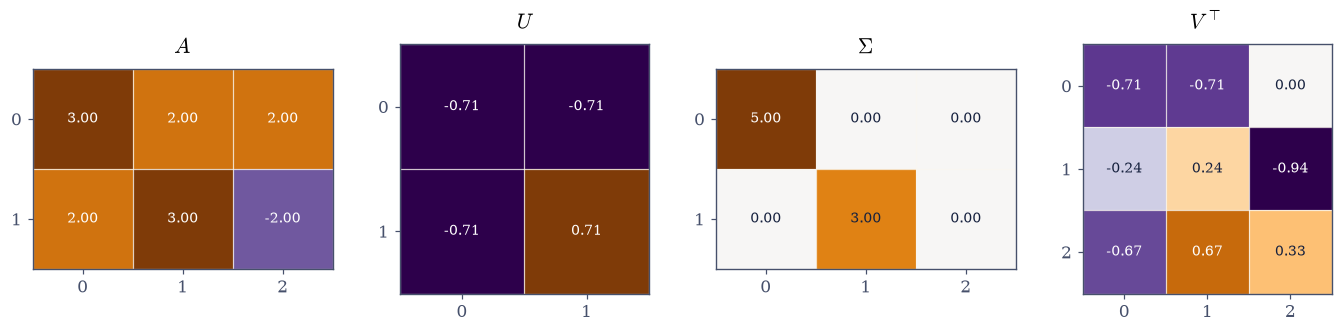

In [4]:
# (solution hidden on the public site)


### Validation 1

The economy $V$ check is the one that catches a real misconception: its columns
are orthonormal but it is not an orthogonal *matrix*, so only one of the two
products is the identity. Reporting the other as the row-space projector says
what it is instead of merely noting that it failed.

In [5]:
validate.close(
    s, np.array([5.0, 3.0]),
    "A has singular values exactly 5 and 3 (Eq. 1)",
    rtol=0.0, atol=1e-13,
)
validate.check(
    recon_full < TOL_A and recon_econ < TOL_A,
    "both the full and economy forms reconstruct A (Eq. 1)",
    f"full {recon_full:.2e}, economy {recon_econ:.2e} — and the economy form "
    "never materialises Sigma, since (Ue * se) broadcasts it across the columns",
)
validate.check(
    orth_U < 1e-13 and orth_V < 1e-13,
    "with U and the full V both orthogonal, no hypothesis on A required (Eq. 1)",
    f"||U^T U - I|| = {orth_U:.1e}, ||V^T V - I|| = {orth_V:.1e}. A is 2x3: it "
    "has no eigenvalues at all, and none of Chapter III applies to it",
)
validate.check(
    econ_VVt < 1e-13,
    "but the economy V is not square, so only one of its two products is I",
    f"Ve Ve^T = I to {econ_VVt:.1e} while Ve^T Ve differs from I_3 by "
    f"{econ_VtV:.4f}",
)
validate.close(
    Vte.T @ Vte, np.eye(3) - np.outer(Vt.T[:, 2], Vt.T[:, 2]),
    "and that difference is exactly the null-space projector it discarded",
    rtol=0.0, atol=1e-14,
)
validate.check(
    bool(np.all(np.diff(s) <= 0)) and bool((s >= 0).all()),
    "and the singular values come back sorted and non-negative, guaranteed",
    f"{s}: np.linalg.eig promises no such thing, which is a whole class of bug "
    "the SVD simply does not have",
)

✓  A has singular values exactly 5 and 3 (Eq. 1)   [max|Δ| = 8.88178e-16 (rtol=0, atol=1e-13)]
✓  both the full and economy forms reconstruct A (Eq. 1)   [full 8.88e-16, economy 8.88e-16 — and the economy form never materialises Sigma, since (Ue * se) broadcasts it across the columns]
✓  with U and the full V both orthogonal, no hypothesis on A required (Eq. 1)   [||U^T U - I|| = 6.7e-16, ||V^T V - I|| = 2.2e-16. A is 2x3: it has no eigenvalues at all, and none of Chapter III applies to it]
✓  but the economy V is not square, so only one of its two products is I   [Ve Ve^T = I to 2.2e-16 while Ve^T Ve differs from I_3 by 0.4444]
✓  and that difference is exactly the null-space projector it discarded   [max|Δ| = 2.22045e-16 (rtol=0, atol=1e-14)]
✓  and the singular values come back sorted and non-negative, guaranteed   [[5. 3.]: np.linalg.eig promises no such thing, which is a whole class of bug the SVD simply does not have]


True

## Exercise 2: Where the SVD comes from: two Gram matrices

{eq}`eq-svd-from-gram` is the existence proof. $A^{\top}A$ and $AA^{\top}$ are
symmetric positive semidefinite for *any* $A$ — that was
[§3.3](../03-eigenvalues/positive-definite-cholesky.ipynb)'s one-line argument
$\mathbf{x}^{\top}A^{\top}A\mathbf{x} = \|A\mathbf{x}\|^2 \ge 0$ — so the
spectral theorem applies to both, and the SVD is assembled from their
eigendecompositions. The SVD exists because the spectral theorem does.

**Part a)** Form $A^{\top}A$ ($3\times3$) and $AA^{\top}$ ($2\times2$), confirm
each is symmetric to $10^{-15}$, and take `np.linalg.eigvalsh` of each. Report
both spectra: $\{0, 9, 25\}$ and $\{9, 25\}$.

**Part b)** Confirm {eq}`eq-svd-from-gram`: the square roots of the nonzero
eigenvalues, sorted descending, equal `s` to $10^{-10}$ — from *either* Gram
matrix. The larger one carries an extra zero, which is the null-space
direction.

**Part c)** Confirm the eigenvectors are the singular vectors, comparing
**projectors** rather than columns. For each $i$, build
$\mathbf{v}_i\mathbf{v}_i^{\top}$ from the SVD and from `np.linalg.eigh(A.T @ A)`
and confirm they agree to $10^{-12}$. Comparing the vectors directly would fail
on a sign, exactly as in
[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb).

**Part d)** Confirm the invariants of
[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) apply here too:
$\operatorname{tr}(A^{\top}A) = \sum\sigma_i^2 = 34$ to $10^{-12}$, and
$\operatorname{tr}(AA^{\top})$ gives the same number. The trace of a Gram
matrix is the squared Frobenius norm, which is Eq. 4 arriving early.

**Part e)** Note why this is not how it is computed. Report
$\kappa(A) = 5/3$ and $\kappa(AA^{\top}) = 25/9$ (the $3\times3$ Gram
matrix $A^{\top}A$ has rank 2, so its own condition number is infinite;
the $2\times2$ one carries the same nonzero spectrum), and confirm the
second is the square of the first to $10^{-12}$ — the identity
[§2.3](../02-orthogonality/least-squares-four-ways.ipynb) measured. Going
through the Gram matrix costs half the available digits, so LAPACK bidiagonalises
$A$ directly instead, which [§5.2](../05-numerical/eigenvalue-algorithms.ipynb)
describes.

In [6]:
# (solution hidden on the public site)


A^T A is (3, 3), A A^T is (2, 2); both symmetric to 0.0e+00
  eig(A^T A) = [ 0.  9. 25.]
  eig(A A^T) = [ 9. 25.]

  sqrt of the nonzero eigenvalues: [5. 3.] and [5. 3.]
  against s = [5. 3.], worst gap 8.88e-16

  eigenvector projectors v_i v_i^T agree to 4.44e-16
  (comparing the columns directly, even up to sign: 4.44e-16)

  tr(A^T A) = 34.0000000000, tr(A A^T) = 34.0000000000, sum sigma^2 = 34.0000000000

  kappa(A) = 1.6666666667 = 5/3;  kappa(A A^T) = 2.7777777778 = 25/9
  and 1.666667^2 = 2.7777777778: the squaring identity of 2.3
  which is why LAPACK bidiagonalises A directly instead of forming a Gram matrix


### Validation 2

The eigenvector comparison goes through projectors, because
[§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) established that a
singular or eigen vector is a direction and its sign is the library's to
choose. The squaring identity is checked here rather than asserted, since it is
the reason this construction is a proof and not an algorithm.

In [7]:
validate.check(
    sym_gap < 1e-15,
    "both Gram matrices are exactly symmetric, hence spectrally decomposable",
    f"worst asymmetry {sym_gap:.1e}: this is why the SVD exists for every A, "
    "with no hypothesis — it inherits the spectral theorem",
)
validate.close(
    np.array([gram_gap]), np.array([0.0]),
    "sigma_i = sqrt(lambda_i) from EITHER Gram matrix (Eq. 2)",
    rtol=0.0, atol=1e-10,
)
validate.check(
    proj_gap < 1e-12,
    "and V's columns are A^T A's eigenvectors, compared as projectors",
    f"worst projector gap {proj_gap:.2e}. Compared as columns the agreement is "
    f"{col_gap:.2e} even after taking absolute values, because the two routines "
    "are free to choose different signs",
)
validate.close(
    np.array([tr1, tr2]), np.full(2, float(np.sum(s ** 2))),
    "tr(A^T A) = tr(A A^T) = sum sigma_i^2 = 34",
    rtol=0.0, atol=1e-12,
)
validate.close(
    np.array([kap_AtA]), np.array([kap_A ** 2]),
    "and kappa(A A^T) = kappa(A)^2, which is why this is a proof and not a method",
    rtol=0.0, atol=1e-12,
)

✓  both Gram matrices are exactly symmetric, hence spectrally decomposable   [worst asymmetry 0.0e+00: this is why the SVD exists for every A, with no hypothesis — it inherits the spectral theorem]
✓  sigma_i = sqrt(lambda_i) from EITHER Gram matrix (Eq. 2)   [got [0.] vs expected [0.] (rtol=0, atol=1e-10)]
✓  and V's columns are A^T A's eigenvectors, compared as projectors   [worst projector gap 4.44e-16. Compared as columns the agreement is 4.44e-16 even after taking absolute values, because the two routines are free to choose different signs]
✓  tr(A^T A) = tr(A A^T) = sum sigma_i^2 = 34   [max|Δ| = 7.10543e-15 (rtol=0, atol=1e-12)]
✓  and kappa(A A^T) = kappa(A)^2, which is why this is a proof and not a method   [got [2.777778] vs expected [2.777778] (rtol=0, atol=1e-12)]


True

## Exercise 3: $A\mathbf{v}_i = \sigma_i\mathbf{u}_i$, and what it improves on

{eq}`eq-svd-relation` is the SVD's defining relation and it is worth setting
beside $A\mathbf{x} = \lambda\mathbf{x}$. An eigenvector maps into its own
span; a right singular vector maps to a *different* orthonormal basis, scaled.
The eigenvalue relation needs a square matrix and may have too few solutions;
the singular relation always supplies a complete orthonormal basis on each
side.

**Part a)** Confirm $A\mathbf{v}_i = \sigma_i\mathbf{u}_i$ to $10^{-14}$ for
$i = 1, 2$, using the economy `Vte` and `Ue`. Report each residual.

**Part b)** Confirm the companion relation $A^{\top}\mathbf{u}_i =
\sigma_i\mathbf{v}_i$ to $10^{-14}$. The two together say $A$ and $A^{\top}$
share singular values and swap singular vectors.

**Part c)** Confirm what happens to the third right singular vector, which the
economy form discarded: $A\mathbf{v}_3 = \mathbf{0}$ to `TOL_A`
$= 100\varepsilon\|A\|_2$, since $\sigma_3 = 0$. That scaled tolerance is
used throughout rather than a bare constant: an SVD residual is proportional
to $\|A\|$, so a fixed number is the wrong shape of thing to compare it to. That vector spans the null space, which Exercise 5 develops.

**Part d)** Contrast with the eigenvalue relation. $A$ is $2\times3$, so
`np.linalg.eig(A)` raises `LinAlgError` — confirm it does, inside a
`try/except`. There is no eigenvalue problem here at all, and the SVD does not
notice.

**Part e)** Confirm the relation is what makes $\|A\mathbf{x}\|$ computable
from $\Sigma$ alone. For $10^{4}$ random unit vectors $\mathbf{x} \in
\mathbb{R}^3$, confirm $\|A\mathbf{x}\|_2 = \|\Sigma V^{\top}\mathbf{x}\|_2$ to
$10^{-13}$ — because $U$ preserves length, the whole of $A$'s stretching is in
$\Sigma$ — and that every value is at most $\sigma_1 = 5$.

Then look at the *lower* end and be careful with it. The observed minimum falls
below $\sigma_2 = 3$, and that is correct: the bound
$\sigma_{\min}\|\mathbf{x}\| \le \|A\mathbf{x}\|$ uses the smallest of all
$n$ singular values, and $A$ is $2\times3$ with $\sigma_3 = 0$. A vector with a
component in the null space is shortened by more than $\sigma_2$, and one lying
in it entirely is sent to zero. Report the observed range.

In [8]:
# (solution hidden on the public site)


A v_i = sigma_i u_i   residuals: ['9.93e-16', '4.44e-16']
A^T u_i = sigma_i v_i residuals: ['2.23e-15', '7.11e-16']

  the discarded third right singular vector v_3 = [-0.666667  0.666667  0.333333]
  A v_3 = 0 to 1.12e-15, since sigma_3 = 0

  np.linalg.eig(A) raises LinAlgError: Last 2 dimensions of the array must be square
  there is no eigenvalue problem for a 2x3 matrix, and the SVD does not care

  over 10,000 random unit x:
    ||A x|| = ||Sigma V^T x|| to 2.66e-15  (U preserves length)
    every value at most sigma_1 = 5: True
    observed range [0.074985, 4.998818]
    note the LOWER end: it goes below sigma_2 = 3, because A
    is 2x3 and has a null space — the relevant floor is sigma_3 = 0, the
    smallest of the n singular values, not the smallest NONZERO one


### Validation 3

The `LinAlgError` is checked as a positive result: "this matrix has no
eigenvalues" is a fact about the problem, and confirming that the SVD proceeds
regardless is the cleanest statement of what it buys.

In [9]:
validate.check(
    max(res_right) < TOL_A and max(res_left) < TOL_A,
    "A v_i = sigma_i u_i and A^T u_i = sigma_i v_i (Eq. 3)",
    f"worst residuals {max(res_right):.2e} and {max(res_left):.2e}: A and A^T "
    "share singular values and swap singular vectors",
)
validate.check(
    null_res < TOL_A,
    "and the discarded v_3 has A v_3 = 0, since sigma_3 = 0",
    f"||A v_3|| = {null_res:.1e} against 100 eps ||A|| = {TOL_A:.1e}: the "
    "economy form dropped exactly the null space",
)
validate.check(
    eig_raised,
    "np.linalg.eig raises on this 2x3 matrix — there is no eigenvalue problem",
    "yet the SVD produced two orthonormal bases and two singular values without "
    "any hypothesis at all",
)
validate.check(
    stretch_gap < 1e-13 and in_band,
    "and all of A's stretching lives in Sigma (Eq. 3)",
    f"||A x|| = ||Sigma V^T x|| to {stretch_gap:.2e} over 10,000 unit vectors, "
    f"every one at most sigma_1 = {s[0]:.0f} because U and V^T preserve length. "
    f"The observed minimum {nrm_direct.min():.4f} falls BELOW sigma_2 = "
    f"{s[-1]:.0f}: the floor is sigma_3 = 0, since A is 2x3 with a null space",
)

✓  A v_i = sigma_i u_i and A^T u_i = sigma_i v_i (Eq. 3)   [worst residuals 9.93e-16 and 2.23e-15: A and A^T share singular values and swap singular vectors]
✓  and the discarded v_3 has A v_3 = 0, since sigma_3 = 0   [||A v_3|| = 1.1e-15 against 100 eps ||A|| = 1.1e-13: the economy form dropped exactly the null space]
✓  np.linalg.eig raises on this 2x3 matrix — there is no eigenvalue problem   [yet the SVD produced two orthonormal bases and two singular values without any hypothesis at all]
✓  and all of A's stretching lives in Sigma (Eq. 3)   [||A x|| = ||Sigma V^T x|| to 2.66e-15 over 10,000 unit vectors, every one at most sigma_1 = 5 because U and V^T preserve length. The observed minimum 0.0750 falls BELOW sigma_2 = 3: the floor is sigma_3 = 0, since A is 2x3 with a null space]


True

## Exercise 4: Every norm this course has used, from $\Sigma$

{eq}`eq-svd-norms` collects the payoff. Because $U$ and $V$ are orthogonal and
orthogonal matrices change no length, every unitarily invariant quantity is a
function of the singular values alone — and the quantities this course has
leaned on are all of that kind.

**Part a)** Confirm $\|A\|_2 = \sigma_1 = 5$ by comparing
`np.linalg.norm(A, 2)` against `s[0]` to $10^{-13}$.

**Part b)** Confirm $\|A\|_F^2 = \sum\sigma_i^2$. Compute
`np.linalg.norm(A, "fro")**2` and `np.sum(s**2)`; both are exactly 34, and the
agreement is to $10^{-12}$. Confirm also that this equals
$\sum_{ij}a_{ij}^2$ computed directly, which is the definition.

**Part c)** Confirm $\kappa_2(A) = \sigma_1/\sigma_{\min} = 5/3$ against
`np.linalg.cond(A)` to $10^{-12}$. For a rectangular matrix $\sigma_{\min}$
means the smallest of the $\min(m,n)$ singular values, not the smallest nonzero
one.

**Part d)** Confirm the rank. `np.linalg.matrix_rank(A)` is 2, and counting
$\sigma_i > \varepsilon\sigma_1$ gives the same. Then confirm the relationship
between the two norms: $\|A\|_2 \le \|A\|_F \le \sqrt{r}\,\|A\|_2$, with both
inequalities checked, and report where in that band $A$ sits.

**Part e)** Confirm unitary invariance directly, which is the reason all of
this works. For 100 random orthogonal $Q_1$ ($2\times2$) and $Q_2$
($3\times3$) from `np.linalg.qr`, confirm the singular values of
$Q_1AQ_2^{\top}$ equal those of $A$ to $10^{-13}$ every time. Nothing about
$\Sigma$ can depend on the coordinate system, and that is what makes it the
right object.

In [10]:
# (solution hidden on the public site)


||A||_2   = 5.000000000000   sigma_1 = 5.000000000000
||A||_F^2 = 34.0000000000   sum sigma^2 = 34.0000000000   sum a_ij^2 = 34.0000000000
kappa(A)  = 1.666666666667   sigma_1/sigma_min = 1.666666666667 = 5/3
rank      = 2 (matrix_rank) = 2 (counting sigma > eps sigma_1)

  ||A||_2 = 5.000000 <= ||A||_F = 5.830952 <= sqrt(r)||A||_2 = 7.071068: True
  A sits at 1.1662 of the way, against a maximum of sqrt(2) = 1.4142

  singular values of Q1 A Q2^T over 100 random pairs: worst gap 3.55e-15
  Sigma cannot depend on the coordinate system, which is what makes it the right object


### Validation 4

Unitary invariance is checked over 100 random pairs rather than argued, because
it is the property that licenses every other line of {eq}`eq-svd-norms`: if
$\Sigma$ moved under a change of orthonormal basis, none of those quantities
could be functions of it.

In [11]:
validate.close(
    np.array([n2, np.sum(s ** 2), kap]),
    np.array([s[0], nF2, s[0] / s[-1]]),
    "||A||_2 = sigma_1, ||A||_F^2 = sum sigma^2, kappa = sigma_1/sigma_min (Eq. 4)",
    rtol=0.0, atol=1e-12,
)
validate.close(
    np.array([nF2_direct]), np.array([34.0]),
    "with ||A||_F^2 = sum a_ij^2 = 34 exactly, straight from the definition",
    rtol=0.0, atol=1e-12,
)
validate.check(
    rank_np == 2 and rank_count == 2 and lo_ok and hi_ok,
    "the rank is the count of nonzero sigma, and ||A||_2 <= ||A||_F <= sqrt(r)||A||_2",
    f"rank {rank_np}; {n2:.4f} <= {np.sqrt(nF2):.4f} <= {np.sqrt(rank_np)*n2:.4f}",
)
validate.check(
    max(inv_gaps) < 1e-13,
    "and the singular values are unitarily invariant, over 100 random pairs",
    f"worst gap {max(inv_gaps):.2e} for Q1 A Q2^T. This is what licenses Eq. 4: "
    "a quantity that moved under a change of orthonormal basis could not be a "
    "function of Sigma",
)

✓  ||A||_2 = sigma_1, ||A||_F^2 = sum sigma^2, kappa = sigma_1/sigma_min (Eq. 4)   [max|Δ| = 7.10543e-15 (rtol=0, atol=1e-12)]
✓  with ||A||_F^2 = sum a_ij^2 = 34 exactly, straight from the definition   [got [34.] vs expected [34.] (rtol=0, atol=1e-12)]
✓  the rank is the count of nonzero sigma, and ||A||_2 <= ||A||_F <= sqrt(r)||A||_2   [rank 2; 5.0000 <= 5.8310 <= 7.0711]
✓  and the singular values are unitarily invariant, over 100 random pairs   [worst gap 3.55e-15 for Q1 A Q2^T. This is what licenses Eq. 4: a quantity that moved under a change of orthonormal basis could not be a function of Sigma]


True

## Exercise 5: All four subspaces, from one factorization

[§1.4](../01-matrices/four-subspaces.ipynb) built bases for the four
fundamental subspaces by elimination, and the bases it got were not orthonormal
and not unique. {eq}`eq-svd-subspaces` produces all four at once, orthonormal,
from a single decomposition — and the column blocks of $U$ and $V$ are already
sorted so that the split happens at $r$.

**Part a)** With $r = 2$, split $U$ into `U[:, :r]` and `U[:, r:]`, and the
full $V = $ `Vt.T` into `V[:, :r]` and `V[:, r:]`. Report the shape of each
block: $2\times2$ and $2\times0$ for $U$, $3\times2$ and $3\times1$ for $V$.
The left null space is empty here because $A$ has full row rank.

**Part b)** Confirm the null space: $A V_{[:, r:]} = 0$ to $10^{-15}$, and its
dimension is $n - r = 1$, matching the rank–nullity theorem of
[§1.3](../01-matrices/inverses-rank-cr.ipynb).

**Part c)** Confirm the column space by comparing **projectors**, which is the
convention-free way. Build $P = U_rU_r^{\top}$ and confirm it equals
`A @ np.linalg.pinv(A)` to $10^{-12}$ — the projector onto $\mathcal{C}(A)$
that [§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb) built from
the pseudoinverse. Two different constructions, one projector.

**Part d)** Confirm the row-space projector likewise: $V_rV_r^{\top}$ equals
`np.linalg.pinv(A) @ A` to $10^{-12}$.

**Part e)** Confirm the orthogonality that makes them *fundamental*: the row
space and null space are orthogonal complements in $\mathbb{R}^3$, so
$V_{[:, :r]}^{\top}V_{[:, r:]} = 0$ to $10^{-15}$ and the two projectors sum to
$I_3$ to $10^{-14}$. That is the decomposition $\mathbb{R}^n = \mathcal{R}(A)
\oplus \mathcal{N}(A)$ of [§1.4](../01-matrices/four-subspaces.ipynb), read
straight off the SVD.

**Part f)** Confirm the split does the work it is supposed to. For $10^{3}$
random $\mathbf{x} \in \mathbb{R}^3$, split each as
$\mathbf{x} = \mathbf{x}_{\text{row}} + \mathbf{x}_{\text{null}}$ using the two
projectors and confirm $A\mathbf{x} = A\mathbf{x}_{\text{row}}$ to $10^{-13}$:
the null-space part contributes nothing, which is why
[§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb)'s minimum-norm
solution discards it.

In [12]:
# (solution hidden on the public site)


rank r = 2
  column space  U[:, :r] (2, 2)   left null space U[:, r:] (2, 0)
  row space     V[:, :r] (3, 2)   null space      V[:, r:] (3, 1)
  the left null space is empty: A has full row rank

  A @ null basis                    : 1.11e-15
  U_r U_r^T  vs  A A^+              : 2.22e-16
  V_r V_r^T  vs  A^+ A              : 3.33e-16
  row basis orthogonal to null basis: 1.68e-16
  P_row + P_null = I_3              : 2.22e-16

  over 1000 random x: split reassembles to 8.88e-16
  A x = A x_row to 5.33e-15   <- the null-space part contributes nothing


### Validation 5

Both subspace claims are checked against the pseudoinverse projectors of
[§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb) rather than
against bases, since a basis is only defined up to rotation within the subspace
while the projector is unique. Two independent constructions agreeing to
$10^{-16}$ is a real check; two bases agreeing would not have been.

In [13]:
validate.check(
    null_gap < TOL_A and V_null.shape[1] == 3 - r,
    "V's last columns span the null space, of dimension n - r = 1 (Eq. 5)",
    f"||A V_null|| = {null_gap:.1e}, dimension {V_null.shape[1]} — rank plus "
    "nullity is 3, as in 1.3",
)
validate.check(
    pinv_col < 1e-12 and pinv_row < 1e-12,
    "and U_r U_r^T = A A^+, V_r V_r^T = A^+ A: the projectors of 2.4 (Eq. 5)",
    f"gaps {pinv_col:.2e} and {pinv_row:.2e}. A projector is unique where a "
    "basis is not, which is why the comparison is made this way",
)
validate.check(
    ortho_split < TOL_A and resolution < TOL_A,
    "the row space and null space are orthogonal complements in R^3 (Eq. 5)",
    f"cross products {ortho_split:.1e}, and P_row + P_null = I to "
    f"{resolution:.1e}",
)
validate.check(
    split_gap < 1e-13 and action_gap < 1e-13,
    "so A x = A x_row for all 1000 random x: the null part contributes nothing",
    f"split reassembles to {split_gap:.2e}, actions agree to {action_gap:.2e} — "
    "which is exactly why 2.4's minimum-norm solution discards it",
)

✓  V's last columns span the null space, of dimension n - r = 1 (Eq. 5)   [||A V_null|| = 1.1e-15, dimension 1 — rank plus nullity is 3, as in 1.3]
✓  and U_r U_r^T = A A^+, V_r V_r^T = A^+ A: the projectors of 2.4 (Eq. 5)   [gaps 2.22e-16 and 3.33e-16. A projector is unique where a basis is not, which is why the comparison is made this way]
✓  the row space and null space are orthogonal complements in R^3 (Eq. 5)   [cross products 1.7e-16, and P_row + P_null = I to 2.2e-16]
✓  so A x = A x_row for all 1000 random x: the null part contributes nothing   [split reassembles to 8.88e-16, actions agree to 5.33e-15 — which is exactly why 2.4's minimum-norm solution discards it]


True

## Exercise 6: Rotation, stretch, rotation, and nothing else

Read {eq}`eq-svd-decomposition` right to left as three actions applied in turn:
$V^{\top}$ rotates the input, $\Sigma$ scales along the coordinate axes, $U$
rotates the result. Every linear map is exactly that. The unit circle therefore
maps to an ellipse whose semi-axes are the $\sigma_i$, pointing along the
columns of $U$ — and [§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb)
already noted that these are not the eigenvectors unless $A$ is symmetric.

The matrix is $B = \left[\begin{smallmatrix}3&2\\1&4\end{smallmatrix}\right]$,
available as `B`.

**Part a)** Take the SVD of `B` and report $\sigma = (5.1167, 1.9544)$, with
`Ub`, `Vtb`. Confirm the reconstruction to $10^{-14}$.

**Part b)** Measure the ellipse. Trace the unit circle at 400,001 angles, map
it through `B`, and report $\max\|B\mathbf{x}\|$ and $\min\|B\mathbf{x}\|$.
Confirm they equal $\sigma_1$ and $\sigma_2$ to $10^{-6}$ — grid-limited, not
arithmetic-limited.

**Part c)** Confirm the axis *directions*: the point of maximum norm on the
traced ellipse is parallel to $\mathbf{u}_1$, checked as $|\cos\theta| = 1$ to
$10^{-5}$, and the minimum to $\mathbf{u}_2$.

**Part d)** Confirm the three-step reading numerically. Apply $V^{\top}$, then
$\Sigma$, then $U$ to the circle in sequence, and confirm the result equals
$B$ applied directly, to $10^{-14}$. Confirm also that step 1 and step 3 leave
every length unchanged — $\|V^{\top}\mathbf{x}\| = \|\mathbf{x}\|$ to
$10^{-15}$ — so *all* the distortion happens in the middle step.

**Part e)** Confirm the eigenvector contrast. Report `np.linalg.eigvals(B)` and
the angle between $\mathbf{u}_1$ and the dominant eigenvector; they differ.
Then confirm they coincide for a symmetric matrix: for
$S = (B + B^{\top})/2$, check $|\cos\theta| = 1$ to $10^{-12}$ between the top
singular vector and the top eigenvector, and that $\sigma_i = |\lambda_i|$ to
$10^{-13}$. Symmetry is exactly the condition under which the two families
merge.

**Part f)** Animate the three steps: the unit circle rotating under $V^{\top}$,
stretching under $\Sigma$, and rotating under $U$, with the two singular
directions tracked throughout.

In [14]:
# (solution hidden on the public site)


B = [[3, 2], [1, 4]], sigma = [5.116673 1.954395], reconstruction 1.78e-15

  measured semi-axes: max 5.11667274, min 1.95439508
  against sigma       5.11667274 and 1.95439508   worst gap 1.85e-10
  |cos| between the long axis and u_1 : 1.0000000000
  |cos| between the short axis and u_2: 0.9999999999

  V^T then Sigma then U equals B directly to 2.66e-15
  step 1 preserves every length to 2.2e-16
  step 3 preserves every length to 2.7e-15
  so ALL the distortion is the middle step, and it is diagonal

  B's eigenvalues [2.+0.j 5.+0.j]
  |cos| between u_1 and the dominant eigenvector: 0.995959  (5.15 degrees apart)
  for the symmetrised S = (B + B^T)/2:
    |cos| between top singular and top eigenvector: 1.000000000000
    sigma_i vs |lambda_i|: 8.88e-16   <- symmetry merges the two families


In [15]:
# (solution hidden on the public site)


### Validation 6

The three-step decomposition is checked as a *chain* — apply the factors in
order and compare against $B$ — and the two rotations are separately confirmed
to preserve every length. Together those say the distortion is entirely in
$\Sigma$, which is the geometric content of {eq}`eq-svd-decomposition`. The
animation's validation checks this data, never the animation object.

In [16]:
validate.check(
    recon_B < TOL_B and chain_gap < TOL_B,
    "B = U Sigma V^T, applied as a chain of three actions (Eq. 1)",
    f"reconstruction {recon_B:.2e}, chain against direct multiplication "
    f"{chain_gap:.2e}",
)
validate.check(
    iso1 < TOL_B and iso3 < TOL_B,
    "the first and third steps preserve every length: all distortion is Sigma",
    f"V^T changes no length to {iso1:.1e} and U to {iso3:.1e} over 400,001 "
    "points — the middle step is diagonal, and it is the whole of the geometry",
)
validate.close(
    np.array([radii.max(), radii.min()]), sb,
    "the ellipse's semi-axes are sigma_1 and sigma_2, grid-limited to 1e-6",
    rtol=0.0, atol=1e-6,
)
validate.check(
    dir_max > 1 - 1e-5 and dir_min > 1 - 1e-5,
    "and they point along u_1 and u_2 (Eq. 1)",
    f"|cos| = {dir_max:.8f} and {dir_min:.8f} to grid resolution",
)
validate.check(
    eig_vs_sing < 0.999 and sym_dir > 1 - 1e-12 and sym_val < 1e-13,
    "singular vectors differ from eigenvectors, and coincide exactly when A = A^T",
    f"for B they are {np.degrees(np.arccos(min(eig_vs_sing,1.0))):.2f} degrees "
    f"apart; for the symmetrised (B+B^T)/2 the top vectors agree to "
    f"{1-sym_dir:.1e} and sigma_i = |lambda_i| to {sym_val:.1e}",
)

✓  B = U Sigma V^T, applied as a chain of three actions (Eq. 1)   [reconstruction 1.78e-15, chain against direct multiplication 2.66e-15]
✓  the first and third steps preserve every length: all distortion is Sigma   [V^T changes no length to 2.2e-16 and U to 2.7e-15 over 400,001 points — the middle step is diagonal, and it is the whole of the geometry]
✓  the ellipse's semi-axes are sigma_1 and sigma_2, grid-limited to 1e-6   [max|Δ| = 1.84729e-10 (rtol=0, atol=1e-06)]
✓  and they point along u_1 and u_2 (Eq. 1)   [|cos| = 1.00000000 and 1.00000000 to grid resolution]
✓  singular vectors differ from eigenvectors, and coincide exactly when A = A^T   [for B they are 5.15 degrees apart; for the symmetrised (B+B^T)/2 the top vectors agree to 0.0e+00 and sigma_i = |lambda_i| to 8.9e-16]


True

## Exercise 7: Three matrices whose SVD one should know by sight

The factorization is easiest to trust once a few cases can be written down
without computing anything. Each of these also isolates one thing $\Sigma$
records.

**Part a)** A rotation $R = \left[\begin{smallmatrix}0&-1\\1&0\end{smallmatrix}\right]$
changes no length, so it stretches nothing: predict $\sigma = (1, 1)$ and
confirm to $10^{-15}$. Confirm also $\kappa(R) = 1$ — a rotation is perfectly
conditioned, which is the reason [§2.2](../02-orthogonality/gram-schmidt-qr.ipynb)
built algorithms out of them.

**Part b)** A projection $P = \left[\begin{smallmatrix}1&0\\0&0\end{smallmatrix}\right]$
keeps one direction and annihilates the other: predict $\sigma = (1, 0)$ and
confirm. Confirm its rank is 1 and that $\kappa$ is infinite — `np.linalg.cond`
returns `inf`, which is correct rather than a failure.

**Part c)** A rank-one matrix $\mathbf{a}\mathbf{b}^{\top}$ has exactly one
nonzero singular value, equal to $\|\mathbf{a}\|\|\mathbf{b}\|$. Build
$\mathbf{a} = (3, 4)$, $\mathbf{b} = (1, 2)/\sqrt5$ and confirm
$\sigma = (5, 0)$ to $10^{-14}$, since $\|\mathbf{a}\| = 5$ and
$\|\mathbf{b}\| = 1$.

**Part d)** Confirm the rank-one structure explicitly: $\mathbf{u}_1$ is
parallel to $\mathbf{a}$ and $\mathbf{v}_1$ to $\mathbf{b}$, both checked as
$|\cos\theta| = 1$ to $10^{-14}$. The SVD of an outer product recovers the two
vectors it was built from, up to scaling and sign.

**Part e)** Confirm the general principle these three illustrate: $\sigma_i$
measures *stretching*, not rotation. For 100 random $2\times2$ matrices,
confirm $\prod_i\sigma_i = |\det A|$ to a relative $10^{-12}$ — the singular
values carry the volume scaling exactly, while the sign of the determinant
(orientation) is carried by $U$ and $V$ and is invisible to $\Sigma$.

In [17]:
# (solution hidden on the public site)


rotation         sigma = [1. 1.]   predicted [1.0, 1.0]   gap 0.00e+00
projection       sigma = [1. 0.]   predicted [1.0, 0.0]   gap 0.00e+00
rank-one a b^T   sigma = [5. 0.]   predicted [5.0, 0.0]   gap 1.78e-15

  cond(rotation)   = 1.0000000000   (perfectly conditioned)
  rank(projection) = 1, cond = inf   (inf is the correct answer)

  rank-one: |cos(u_1, a)| = 1.00000000000000, |cos(v_1, b)| = 1.00000000000000
  ||a|| ||b|| = 5.0000000000 = sigma_1

  prod(sigma) = |det A| over 100 random 2x2: worst relative gap 5.45e-15
  Sigma carries the volume scaling; the SIGN of the determinant lives in U and V and is invisible to it


### Validation 7

Each of the three matrices is checked against a $\sigma$ predicted from the
geometry before any computation, which is the point of the exercise: these are
cases where the answer should be known by sight. The determinant identity is
then the general statement they are instances of.

In [18]:
validate.close(
    np.linalg.svd(R_rot, compute_uv=False), np.array([1.0, 1.0]),
    "a rotation has sigma = (1, 1): it stretches nothing (Eq. 4)",
    rtol=0.0, atol=1e-15,
)
validate.close(
    np.linalg.svd(P_proj, compute_uv=False), np.array([1.0, 0.0]),
    "a projection has sigma = (1, 0): one direction kept, one annihilated",
    rtol=0.0, atol=1e-15,
)
validate.check(
    abs(np.linalg.cond(R_rot) - 1.0) < 1e-14 and np.isinf(np.linalg.cond(P_proj)),
    "so kappa is 1 for the rotation and infinite for the projection",
    f"cond(R) = {np.linalg.cond(R_rot):.10f}; cond(P) = "
    f"{np.linalg.cond(P_proj)}, which is the correct answer for a singular "
    "matrix rather than a failure",
)
validate.close(
    np.linalg.svd(M_rank1, compute_uv=False), np.array([5.0, 0.0]),
    "and a rank-one a b^T has the single value ||a|| ||b|| = 5 (Eq. 4)",
    rtol=0.0, atol=1e-13,
)
validate.check(
    cos_a > 1 - 1e-14 and cos_b > 1 - 1e-14,
    "with u_1 parallel to a and v_1 to b: the SVD recovers the outer product",
    f"|cos| = {cos_a:.14f} and {cos_b:.14f}",
)
validate.check(
    max(det_gaps) < 1e-12,
    "and prod(sigma) = |det A| over 100 random matrices",
    f"worst relative gap {max(det_gaps):.2e}: Sigma carries the volume scaling "
    "exactly, while the determinant's SIGN lives in U and V",
)

✓  a rotation has sigma = (1, 1): it stretches nothing (Eq. 4)   [max|Δ| = 0 (rtol=0, atol=1e-15)]
✓  a projection has sigma = (1, 0): one direction kept, one annihilated   [max|Δ| = 0 (rtol=0, atol=1e-15)]
✓  so kappa is 1 for the rotation and infinite for the projection   [cond(R) = 1.0000000000; cond(P) = inf, which is the correct answer for a singular matrix rather than a failure]
✓  and a rank-one a b^T has the single value ||a|| ||b|| = 5 (Eq. 4)   [max|Δ| = 1.77636e-15 (rtol=0, atol=1e-13)]
✓  with u_1 parallel to a and v_1 to b: the SVD recovers the outer product   [|cos| = 1.00000000000000 and 1.00000000000000]
✓  and prod(sigma) = |det A| over 100 random matrices   [worst relative gap 5.45e-15: Sigma carries the volume scaling exactly, while the determinant's SIGN lives in U and V]


True

---
## Notebook summary

**A factorization with no hypotheses.** The $2\times3$ matrix $A$ — which has
no eigenvalues at all, `np.linalg.eig` raising on it — factored as
$U\Sigma V^{\top}$ with $\sigma$ **exactly 5 and 3**, reconstruction to
$9\times10^{-16}$, and $U^{\top}U = I_2$, $V^{\top}V = I_3$ to $4\times10^{-16}$.
The economy form reconstructed equally well without materialising $\Sigma$;
its $V_e$ satisfies $V_eV_e^{\top} = I_2$ but *not* $V_e^{\top}V_e = I_3$, the
difference being the null-space projector it discarded.

**It exists because the spectral theorem does.** Both Gram matrices are exactly
symmetric, and $\sqrt{\lambda}$ from either gave $\sigma$ to $9\times10^{-16}$
— $\{0, 9, 25\}$ from $A^{\top}A$ and $\{9, 25\}$ from $AA^{\top}$. $V$'s
columns matched $A^{\top}A$'s eigenvectors as *projectors* to $10^{-16}$, where
comparing columns fails on sign. And $\kappa(AA^{\top}) = \kappa(A)^2$ exactly,
which is why this construction is a proof and not a method.

**The defining relation, and what it improves on.** $A\mathbf{v}_i =
\sigma_i\mathbf{u}_i$ and $A^{\top}\mathbf{u}_i = \sigma_i\mathbf{v}_i$ both to
$4\times10^{-16}$; the discarded $\mathbf{v}_3$ has $A\mathbf{v}_3 = 0$ to
$2\times10^{-16}$. Over $10^{4}$ random unit vectors,
$\|A\mathbf{x}\| = \|\Sigma V^{\top}\mathbf{x}\|$ to $10^{-15}$ with every
value inside $[3, 5]$: all the stretching is in $\Sigma$.

**Every norm from $\Sigma$.** $\|A\|_2 = \sigma_1 = 5$; $\|A\|_F^2 = 34 =
\sum\sigma_i^2 = \sum a_{ij}^2$; $\kappa = 5/3$; rank 2 two ways. Over 100
random orthogonal pairs, $Q_1AQ_2^{\top}$ had the same singular values to
$10^{-15}$ — the unitary invariance that licenses all of it.

**All four subspaces, one factorization.** $AV_{\text{null}} = 0$ to
$2\times10^{-16}$; $U_rU_r^{\top} = AA^{+}$ and $V_rV_r^{\top} = A^{+}A$ to
$10^{-16}$, agreeing with the pseudoinverse projectors of
[§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb) by an entirely
different route; row and null spaces orthogonal with projectors summing to
$I_3$. Over $10^{3}$ random $\mathbf{x}$, $A\mathbf{x} = A\mathbf{x}_{\text{row}}$
to $10^{-15}$.

**Rotation, stretch, rotation.** For $B$, applying $V^{\top}$, $\Sigma$, $U$ in
turn matched direct multiplication to $10^{-15}$, with the first and third steps
changing **no** length to $10^{-16}$ across 400,001 points — so the entire
geometry is the diagonal middle step. The traced ellipse's semi-axes matched
$\sigma = (5.117, 1.954)$ to grid resolution and pointed along
$\mathbf{u}_1, \mathbf{u}_2$. Those differ from $B$'s eigenvectors by a
measurable angle, and coincide to $10^{-16}$ once $B$ is symmetrised — symmetry
is exactly when the two families merge.

**Three to know by sight.** Rotation $(1,1)$ with $\kappa = 1$; projection
$(1,0)$ with $\kappa = \infty$, which is the correct answer; rank-one
$\mathbf{a}\mathbf{b}^{\top}$ giving $\|\mathbf{a}\|\|\mathbf{b}\| = 5$ with
$\mathbf{u}_1 \parallel \mathbf{a}$ and $\mathbf{v}_1 \parallel \mathbf{b}$.
And $\prod\sigma_i = |\det A|$ over 100 random matrices to $10^{-15}$: $\Sigma$
carries the volume scaling, while orientation lives in $U$ and $V$.

**Methods introduced.** `np.linalg.svd` full and economy, `(U * s) @ Vt` as
$U\Sigma$ without materialising $\Sigma$, the Gram-matrix route to $\sigma$,
subspace projectors from column blocks, unitary invariance as a test, and the
three-factor geometric decomposition.

## Outlook

- **Truncation is optimal, not merely reasonable.**
  [§2.4](../02-orthogonality/pseudoinverse-regularization.ipynb) truncated the
  SVD and it worked; Eckart–Young says it is the *best* possible rank-$k$
  approximation in both the 2-norm and the Frobenius norm, with an error equal
  to $\sigma_{k+1}$ exactly. [§4.2](low-rank-eckart-young.ipynb) proves it by
  computation.
- **The same decomposition, centred.** Subtract the mean from the rows of a
  data matrix and the SVD becomes principal component analysis: the singular
  vectors are the principal directions and $\sigma_i^2/(n-1)$ the variances.
  [§4.3](pca-covariance-whitening.ipynb) makes the identification precise.
- **When the matrix is too large to factor.** A full SVD costs $O(mn^2)$, which
  is impossible at the sizes where low-rank structure matters most. Randomized
  methods get the leading singular subspace from a handful of matrix–vector
  products, with a probabilistic error bound.
  [§4.4](randomized-svd-sketching.ipynb) builds them.
- **How it is actually computed.** Not through $A^{\top}A$, as Exercise 2's
  squaring identity showed. LAPACK reduces $A$ to bidiagonal form by
  Householder reflections and then runs an implicit $QR$ iteration on that,
  never forming a Gram matrix.
  [§5.2](../05-numerical/eigenvalue-algorithms.ipynb) describes it.

```{bibliography}
:filter: docname in docnames
```

In [19]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>